# Inferência Local — Detecção de Rachaduras
Roda o modelo fine-tunado localmente em imagens ou pasta inteira.

In [ ]:
# Instalação
#%pip install ultralytics opencv-python-headless matplotlib -q


In [ ]:
# Parâmetros
from pathlib import Path

# Caminho pro peso treinado
MODELO = Path('C:\\Users\\f\\Desktop\\bootcamp\\2 - Modelagem Preditiva\\Desafio\\Dados\\Desafio-2\\finetunning yolo\\best.pt')

# Fonte de entrada 
FONTE = Path(r'C:\Users\f\Desktop\bootcamp\2 - Modelagem Preditiva\Desafio\Dados\Desafio-2\finetunning yolo\teste')   # pasta com imagens
# FONTE = Path('foto.jpg') # imagem única

# Confiança mínima pra considerar uma detecção
CONF = 0.25

# Salvar imagens anotadas?
SALVAR = True
PASTA_SAIDA = Path('resultados/')


## Carregar modelo

In [8]:
from ultralytics import YOLO

model = YOLO(str(MODELO))
print(f'✅ Modelo carregado: {MODELO}')
print(f'   Parâmetros: {sum(p.numel() for p in model.model.parameters()):,}')


✅ Modelo carregado: C:\Users\f\Desktop\bootcamp\2 - Modelagem Preditiva\Desafio\Dados\Desafio-2\finetunning yolo\best.pt
   Parâmetros: 11,790,483


## Inferência

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

extensoes = ('.jpg', '.jpeg', '.png', '.bmp','jfif')

# Coleta arquivos
if FONTE.is_dir():
    arquivos = sorted([p for p in FONTE.iterdir() if p.suffix.lower() in extensoes])
else:
    arquivos = [FONTE]

print(f'📂 {len(arquivos)} imagem(ns) encontrada(s)')

if SALVAR:
    PASTA_SAIDA.mkdir(parents=True, exist_ok=True)

resultados_inf = []

for i, caminho in enumerate(arquivos):
    r = model.predict(str(caminho), conf=CONF, verbose=False)[0]
    n_det = len(r.boxes) if r.boxes is not None else 0
    resultados_inf.append((caminho, r, n_det))
    print(f'[{i+1}/{len(arquivos)}] {caminho.name} — {n_det} rachadura(s)')

    if SALVAR:
        img_out = r.plot()
        cv2.imwrite(str(PASTA_SAIDA / caminho.name), img_out)

print(f'\n✅ Inferência concluída.')
if SALVAR:
    print(f'📁 Resultados salvos em: {PASTA_SAIDA.resolve()}')


📂 40 imagem(ns) encontrada(s)
[1/40] 1444.rf.88d536239aaf1ebf843bf9455e994aa8.jpg — 3 rachadura(s)
[2/40] 1468.rf.3155bf4e81a07c39d2a7b87338355d93.jpg — 2 rachadura(s)
[3/40] 1557.rf.10d82cc2d84158069151b6096801a524.jpg — 2 rachadura(s)
[4/40] 1603.rf.3af76369edafa227b85524b01c8739e4.jpg — 3 rachadura(s)
[5/40] 1604.rf.b3a82801065a16369dd5535ff27a4bb9.jpg — 1 rachadura(s)
[6/40] 1605.rf.2a8f65a8d8e7daffa47e79775baf657e.jpg — 1 rachadura(s)
[7/40] 1607.rf.7d0ad2fe068f3287adcacd66a10ce92b.jpg — 3 rachadura(s)
[8/40] 1608.rf.40fd9efc8212371de115fec0c0bfbf09.jpg — 4 rachadura(s)
[9/40] 1610.rf.4c98f90bc6e2877d4a0a0c79e052c554.jpg — 4 rachadura(s)
[10/40] 1613.rf.05cc13b8e4e69fc69eef48e1e1aa64ab.jpg — 1 rachadura(s)
[11/40] 1614.rf.28de0245df6b2a5d57b12e31b684c25d.jpg — 1 rachadura(s)
[12/40] 1616.rf.01076132657d8625e2a27c15549bd8bb.jpg — 3 rachadura(s)
[13/40] 1628.rf.1c06f8fcdd338bc615a87a29f9a2b82f.jpg — 1 rachadura(s)
[14/40] 1629.rf.9f4833e0e4c21b80c552179f228945bd.jpg — 3 rachadura(s)

## Visualização — grade de resultados

C:\Users\f\AppData\Local\Temp\ipykernel_40280\335771607.py:21: UserWarning: Glyph 128297 (\N{NUT AND BOLT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


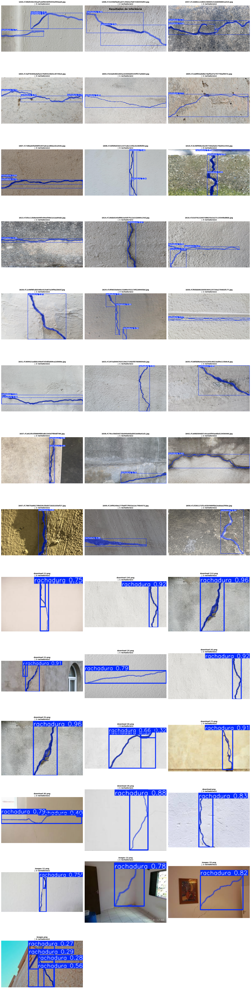

In [10]:
n = len(resultados_inf)
if n == 0:
    print('Nenhuma imagem processada.')
else:
    cols = min(3, n)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 6 * rows))
    axes = np.array(axes).ravel()

    for ax, (caminho, r, n_det) in zip(axes, resultados_inf):
        img_plot = cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB)
        ax.imshow(img_plot)
        ax.set_title(f'{caminho.name}\n🔩 {n_det} rachadura(s)', fontsize=10, fontweight='bold')
        ax.axis('off')

    for ax in axes[len(resultados_inf):]:
        ax.axis('off')

    plt.suptitle('Resultados de Inferência', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


## Resumo

In [12]:
total_rachaduras = sum(n for _, _, n in resultados_inf)
com_rachadura    = sum(1 for _, _, n in resultados_inf if n > 0)
sem_rachadura    = len(resultados_inf) - com_rachadura

print(f'{'Imagem':<35} {'Rachaduras':>12}')
print('-' * 50)
for caminho, _, n_det in resultados_inf:
    flag = '⚠️ ' if n_det > 0 else '✅ '
    print(f'{flag}{caminho.name:<33} {n_det:>12}')
print('-' * 50)
print(f'Total de imagens    : {len(resultados_inf)}')
print(f'Com rachadura       : {com_rachadura}')
print(f'Sem rachadura       : {sem_rachadura}')
print(f'Total de detecções  : {total_rachaduras}')


Imagem                                Rachaduras
--------------------------------------------------
⚠️ 1444.rf.88d536239aaf1ebf843bf9455e994aa8.jpg            3
⚠️ 1468.rf.3155bf4e81a07c39d2a7b87338355d93.jpg            2
⚠️ 1557.rf.10d82cc2d84158069151b6096801a524.jpg            2
⚠️ 1603.rf.3af76369edafa227b85524b01c8739e4.jpg            3
⚠️ 1604.rf.b3a82801065a16369dd5535ff27a4bb9.jpg            1
⚠️ 1605.rf.2a8f65a8d8e7daffa47e79775baf657e.jpg            1
⚠️ 1607.rf.7d0ad2fe068f3287adcacd66a10ce92b.jpg            3
⚠️ 1608.rf.40fd9efc8212371de115fec0c0bfbf09.jpg            4
⚠️ 1610.rf.4c98f90bc6e2877d4a0a0c79e052c554.jpg            4
⚠️ 1613.rf.05cc13b8e4e69fc69eef48e1e1aa64ab.jpg            1
⚠️ 1614.rf.28de0245df6b2a5d57b12e31b684c25d.jpg            1
⚠️ 1616.rf.01076132657d8625e2a27c15549bd8bb.jpg            3
⚠️ 1628.rf.1c06f8fcdd338bc615a87a29f9a2b82f.jpg            1
⚠️ 1629.rf.9f4833e0e4c21b80c552179f228945bd.jpg            3
⚠️ 1630.rf.f65bb063305b364125734a270402fc77.jp

## Inspecionar máscara bruta

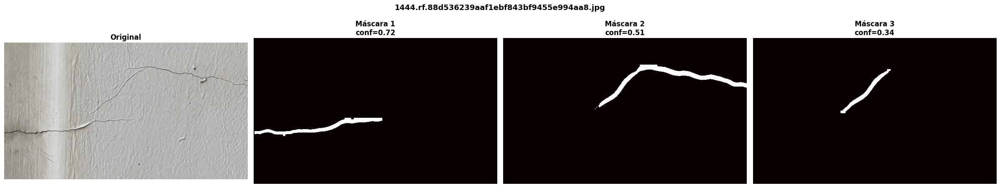

In [11]:
# Mostra a máscara binária de uma imagem específica
INDICE = 0  # ← índice da imagem que quer inspecionar

caminho, r, n_det = resultados_inf[INDICE]

if r.masks is not None and len(r.masks) > 0:
    fig, axes = plt.subplots(1, n_det + 1, figsize=(6 * (n_det + 1), 5))
    if n_det == 0:
        axes = [axes]
    axes = np.array(axes).ravel()

    # Imagem original
    img_rgb = cv2.cvtColor(cv2.imread(str(caminho)), cv2.COLOR_BGR2RGB)
    axes[0].imshow(img_rgb)
    axes[0].set_title('Original', fontweight='bold')
    axes[0].axis('off')

    # Cada máscara individual
    for j, mask in enumerate(r.masks.data):
        m = mask.cpu().numpy()
        axes[j + 1].imshow(m, cmap='hot')
        conf = float(r.boxes.conf[j])
        axes[j + 1].set_title(f'Máscara {j+1}\nconf={conf:.2f}', fontweight='bold')
        axes[j + 1].axis('off')

    plt.suptitle(f'{caminho.name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f'Nenhuma máscara detectada em {caminho.name}')
